In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [13]:
df = pd.read_csv('/Users/artempolyakov/Documents/Курсы/СкилФектори/IDE/Блок 1 (прочие файлы)/Viz/churn.csv')

df['CustomerId'].nunique()


10000

##  9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

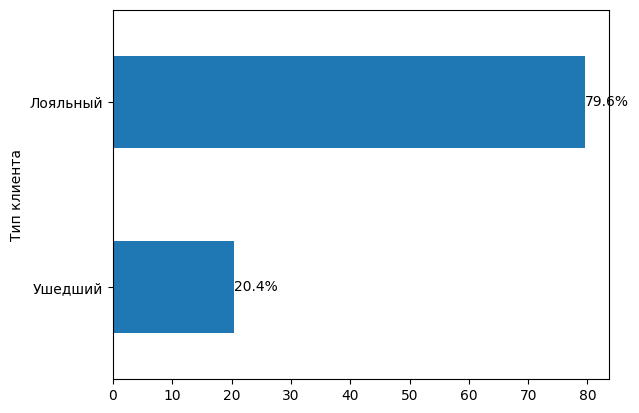

In [ ]:
df['Exited_2'] = np.where(
    df['Exited'] == 0,
    'Лояльный',
    'Ушедший'
)

data = (
    df['Exited_2']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = data.plot(kind='barh')
ax.set_ylabel('Тип клиента')
ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

## 9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

In [39]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Exited_2,geo_color
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Ушедший,blue
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Лояльный,green
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Ушедший,blue
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Лояльный,blue
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Лояльный,green


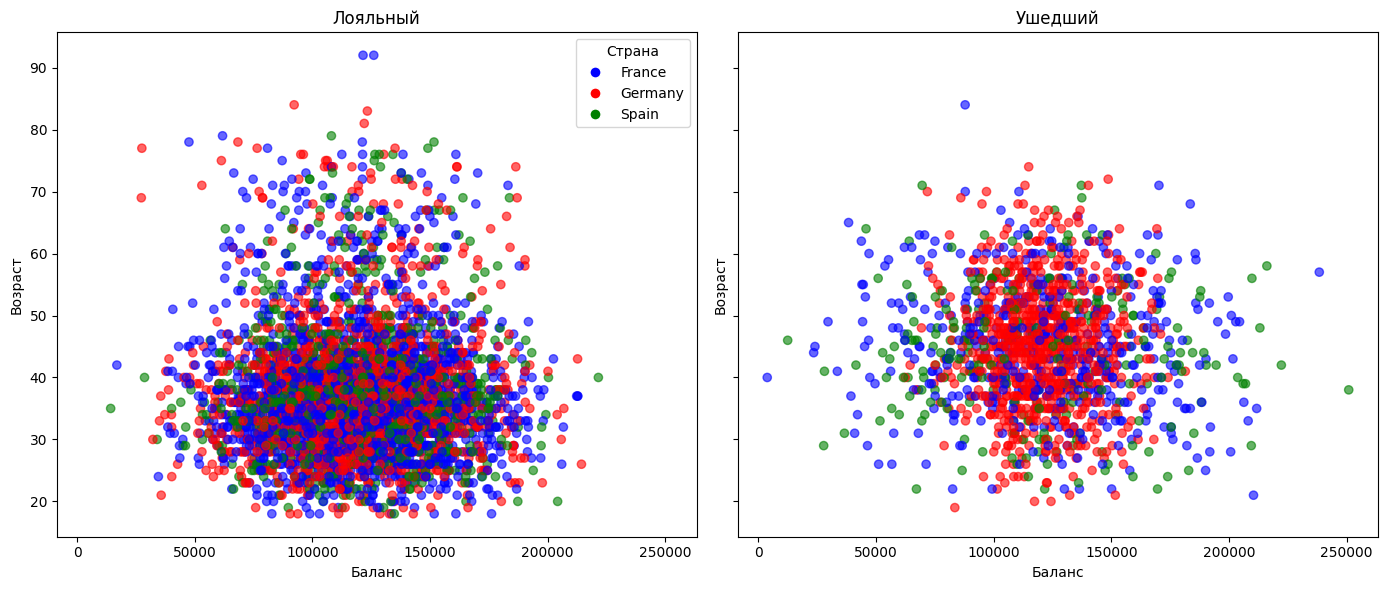

In [32]:
df.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Exited_2
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Лояльный
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7963
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,NaN
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,NaN
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,NaN
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,NaN
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,NaN
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,NaN


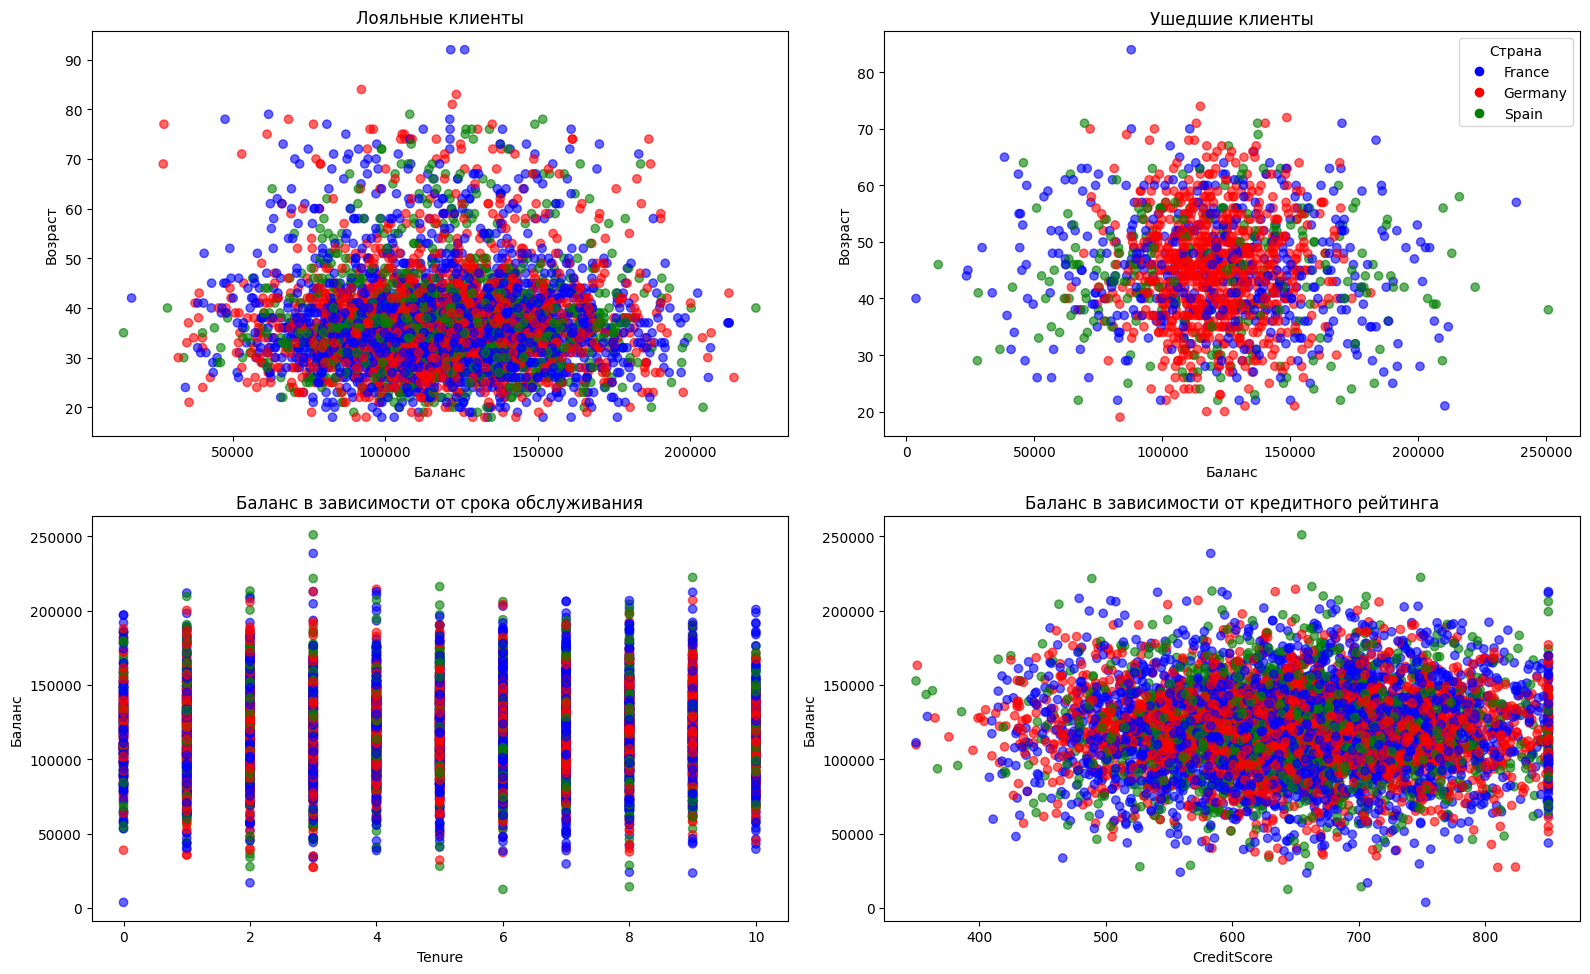

In [54]:

df2 = df.loc[df['Balance'] >= 2500].copy()

df2['geo_color'] = df2['Geography'].map({
    'France': 'blue',
    'Germany': 'red',
    'Spain': 'green'
})

loyal = df2['Exited_2'] == 'Лояльный'
gone = df2['Exited_2'] == 'Ушедший'

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10)
)

# 1 график: баланс / возраст, лояльные
axes[0, 0].scatter(
    df2.loc[loyal, 'Balance'],
    df2.loc[loyal, 'Age'],
    c=df2.loc[loyal, 'geo_color'],
    alpha=0.6
)

axes[0, 0].set_title('Лояльные клиенты')
axes[0, 0].set_xlabel('Баланс')
axes[0, 0].set_ylabel('Возраст')


# 2 график: баланс / возраст, ушедшие
axes[0, 1].scatter(
    df2.loc[gone, 'Balance'],
    df2.loc[gone, 'Age'],
    c=df2.loc[gone, 'geo_color'],
    alpha=0.6
)

axes[0, 1].set_title('Ушедшие клиенты')
axes[0, 1].set_xlabel('Баланс')
axes[0, 1].set_ylabel('Возраст')


# 3 график: баланс в зависимости от Tenure
axes[1, 0].scatter(
    df2['Tenure'],
    df2['Balance'],
    c=df2['geo_color'],
    alpha=0.6
)

axes[1, 0].set_title('Баланс в зависимости от срока обслуживания')
axes[1, 0].set_xlabel('Tenure')
axes[1, 0].set_ylabel('Баланс')


# 4 график: баланс в зависимости от CreditScore
axes[1, 1].scatter(
    df2['CreditScore'],
    df2['Balance'],
    c=df2['geo_color'],
    alpha=0.6
)

axes[1, 1].set_title('Баланс в зависимости от кредитного рейтинга')
axes[1, 1].set_xlabel('CreditScore')
axes[1, 1].set_ylabel('Баланс')


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='France', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Germany', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Spain', markerfacecolor='green', markersize=8)
]

axes[0, 1].legend(
    handles=legend_elements,
    title='Страна'
)

plt.suptitle('')
plt.tight_layout()
plt.show()

Зависимостей не было найдено

## 9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

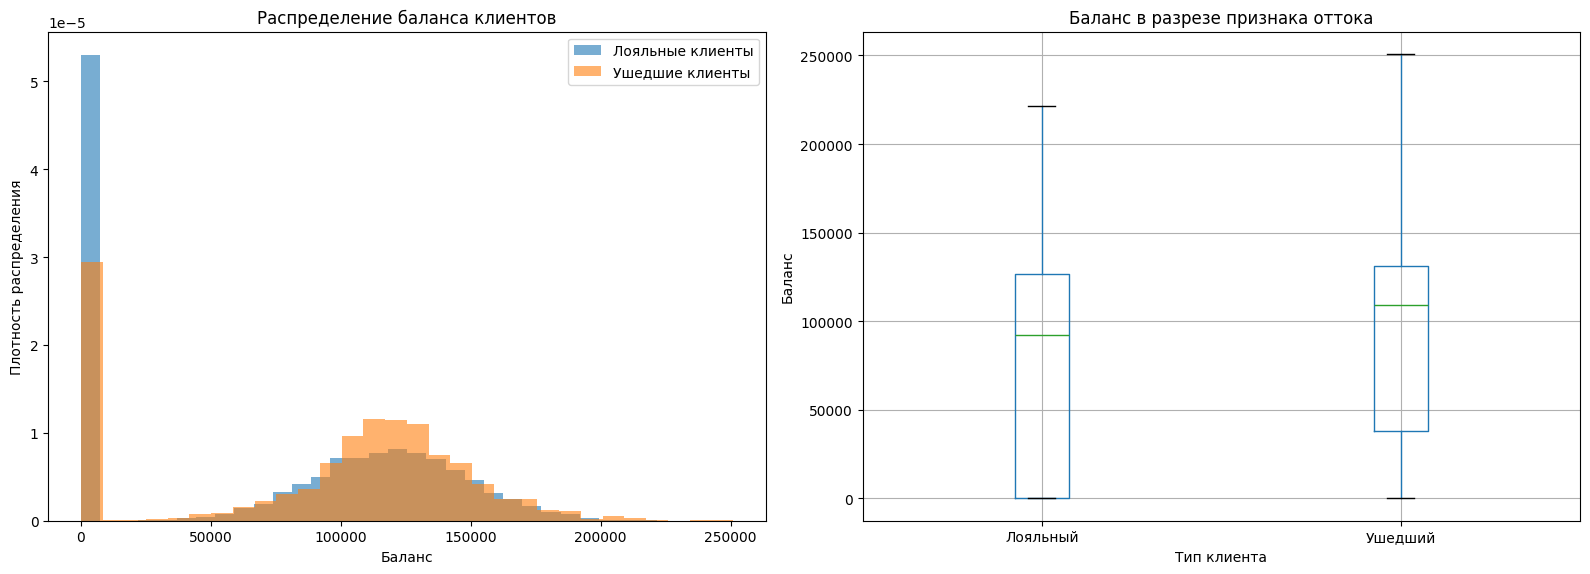

In [47]:


df['Exited_2'] = np.where(
    df['Exited'] == 0,
    'Лояльный',
    'Ушедший'
)

loyal = df['Exited_2'] == 'Лояльный'
gone = df['Exited_2'] == 'Ушедший'

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# 1 график - распределение баланса
axes[0].hist(
    df.loc[loyal, 'Balance'],
    bins=30,
    alpha=0.6,
    label='Лояльные клиенты',
    density=True
)

axes[0].hist(
    df.loc[gone, 'Balance'],
    bins=30,
    alpha=0.6,
    label='Ушедшие клиенты',
    density=True
)

axes[0].set_title('Распределение баланса клиентов')
axes[0].set_xlabel('Баланс')
axes[0].set_ylabel('Плотность распределения')
axes[0].legend()


# 2 график - сравнение баланса через boxplot
df.boxplot(
    column='Balance',
    by='Exited_2',
    ax=axes[1]
)

axes[1].set_title('Баланс в разрезе признака оттока')
axes[1].set_xlabel('Тип клиента')
axes[1].set_ylabel('Баланс')

plt.suptitle('')
plt.tight_layout()
plt.show()

Распределение баланса показывает, что ушедшие клиенты в среднем имеют более высокий баланс на счёте, чем лояльные

## 9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

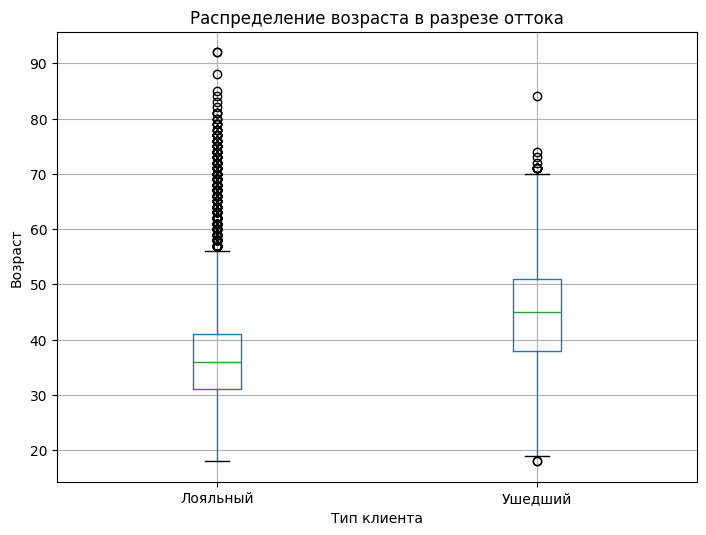

In [53]:

df.boxplot(
    column='Age',
    by='Exited_2',
    figsize=(8, 6)
)

plt.title('Распределение возраста в разрезе оттока')
plt.suptitle('')
plt.xlabel('Тип клиента')
plt.ylabel('Возраст')
plt.show()

Выбросов больше в Лояльной группе. Обратить внимание стоит на возрастную группу 40-50 лет.

## 9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

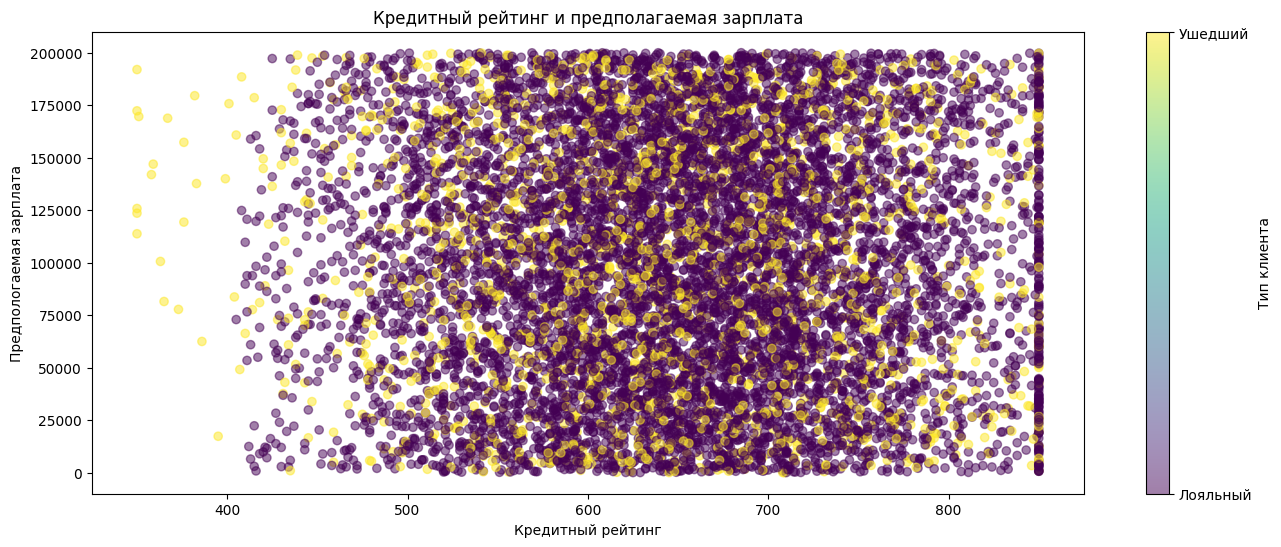

In [66]:


fig, ax = plt.subplots(figsize=(16, 6))

scatter = ax.scatter(
    df['CreditScore'],
    df['EstimatedSalary'],
    c=df['Exited'],
    alpha=0.5
)

ax.set_title('Кредитный рейтинг и предполагаемая зарплата')
ax.set_xlabel('Кредитный рейтинг')
ax.set_ylabel('Предпологаемая зарплата')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Тип клиента')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Лояльный', 'Ушедший'])

plt.show()

Связи нет

## 9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

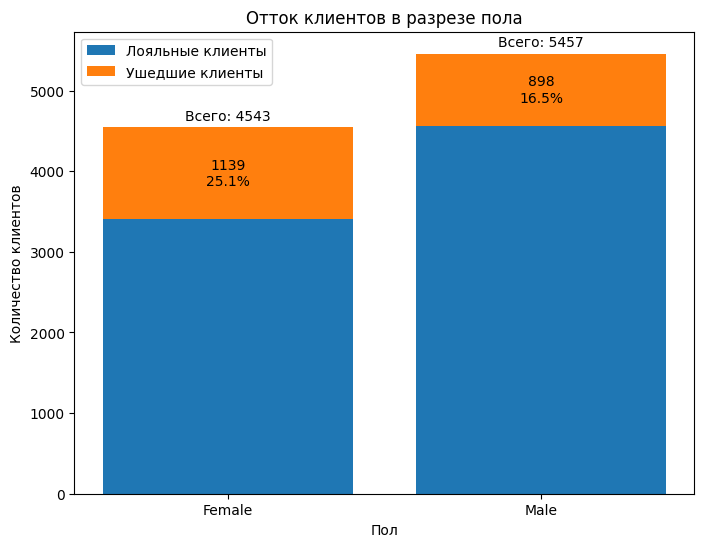

In [ ]:
import matplotlib.pyplot as plt


result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('Gender')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
)

# Считаем количество лояльных и долю ушедших
result['Количество_лояльных'] = (
    result['Количество_всего'] - result['Количество_ушедших']
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(1)


# Строим график
fig, ax = plt.subplots(figsize=(8, 6))

bars_loyal = ax.bar(
    result['Gender'],
    result['Количество_лояльных'],
    label='Лояльные клиенты'
)

bars_exited = ax.bar(
    result['Gender'],
    result['Количество_ушедших'],
    bottom=result['Количество_лояльных'],
    label='Ушедшие клиенты'
)


# Подпись внутри части с ушедшими
ax.bar_label(
    bars_exited,
    labels=[
        f"{row['Количество_ушедших']}\n{row['Доля_ушедших_%']}%"
        for _, row in result.iterrows()
    ],
    label_type='center'
)

# Подпись общего количества сверху столбца
ax.bar_label(
    bars_exited,
    labels=[
        f"Всего: {row['Количество_всего']}"
        for _, row in result.iterrows()
    ],
    label_type='edge',
    padding=3
)


ax.set_title('Отток клиентов в разрезе пола')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество клиентов')
ax.legend()

plt.show()

Чаще уходят женщины

## 9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

In [83]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Exited_2,geo_color
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Ушедший,blue
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Лояльный,green
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Ушедший,blue
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Лояльный,blue
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Лояльный,green


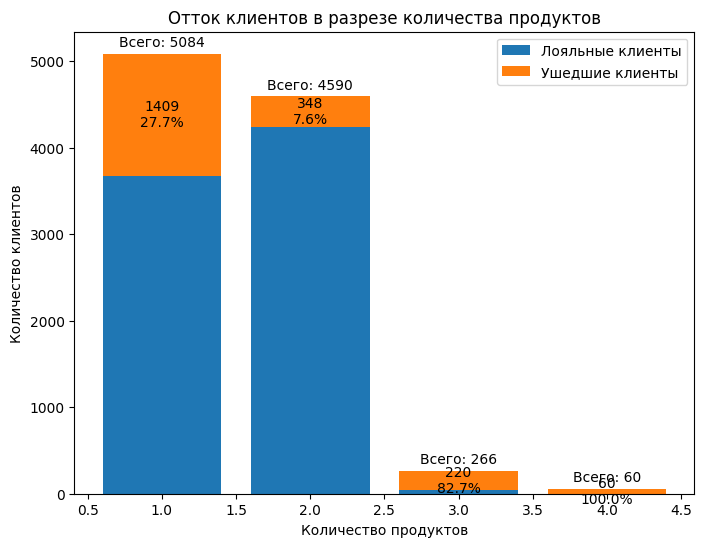

In [ ]:

# Сначала готовим таблицу
result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('NumOfProducts')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
    .sort_values('NumOfProducts')
)

# Считаем количество лояльных и долю ушедших
result['Количество_лояльных'] = (
    result['Количество_всего'] - result['Количество_ушедших']
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(1)

# Готовим подписи
labels_exited = (
    result['Количество_ушедших'].astype(str)
    + '\n'
    + result['Доля_ушедших_%'].astype(str)
    + '%'
)

labels_total = (
    'Всего: '
    + result['Количество_всего'].astype(str)
)

# Строим график
fig, ax = plt.subplots(figsize=(8, 6))

bars_loyal = ax.bar(
    result['NumOfProducts'],
    result['Количество_лояльных'],
    label='Лояльные клиенты'
)

bars_exited = ax.bar(
    result['NumOfProducts'],
    result['Количество_ушедших'],
    bottom=result['Количество_лояльных'],
    label='Ушедшие клиенты'
)

# Подпись внутри части с ушедшими
ax.bar_label(
    bars_exited,
    labels=labels_exited,
    label_type='center'
)

# Подпись общего количества сверху столбца
ax.bar_label(
    bars_exited,
    labels=labels_total,
    label_type='edge',
    padding=3
)

ax.set_title('Отток клиентов в разрезе количества продуктов')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Количество клиентов')
ax.legend()

plt.show()

Чем больще продуктов использует клиент - тем чаще уходит. Оптимальный вариант 2 продукта

## 9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

In [88]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Exited_2,geo_color
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Ушедший,blue
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Лояльный,green
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Ушедший,blue
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Лояльный,blue
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Лояльный,green


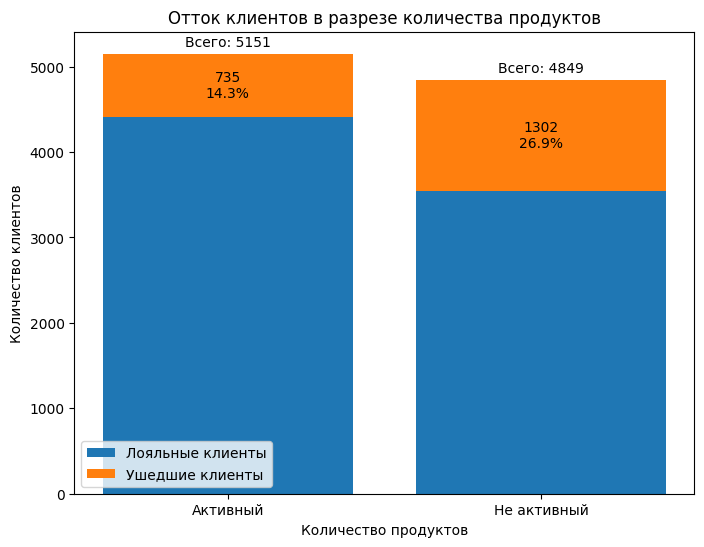

In [91]:
df['Activ_user'] = np.where(
    df['IsActiveMember'] == 0,
    'Не активный',
    'Активный'
)


# Сначала готовим таблицу
result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('Activ_user')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
    .sort_values('Activ_user')
)

# Считаем количество лояльных и долю ушедших
result['Количество_лояльных'] = (
    result['Количество_всего'] - result['Количество_ушедших']
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(1)

# Готовим подписи
labels_exited = (
    result['Количество_ушедших'].astype(str)
    + '\n'
    + result['Доля_ушедших_%'].astype(str)
    + '%'
)

labels_total = (
    'Всего: '
    + result['Количество_всего'].astype(str)
)

# Строим график
fig, ax = plt.subplots(figsize=(8, 6))

bars_loyal = ax.bar(
    result['Activ_user'],
    result['Количество_лояльных'],
    label='Лояльные клиенты'
)

bars_exited = ax.bar(
    result['Activ_user'],
    result['Количество_ушедших'],
    bottom=result['Количество_лояльных'],
    label='Ушедшие клиенты'
)

# Подпись внутри части с ушедшими
ax.bar_label(
    bars_exited,
    labels=labels_exited,
    label_type='center'
)

# Подпись общего количества сверху столбца
ax.bar_label(
    bars_exited,
    labels=labels_total,
    label_type='edge',
    padding=3
)

ax.set_title('Отток клиентов в разрезе количества продуктов')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Количество клиентов')
ax.legend()

plt.show()

Доля ухода неактивных пользователей выше

## 9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

In [96]:
result = (
    df.assign(
        CustomerId_exited=df['CustomerId'].where(df['Exited_2'] == 'Ушедший')
    )
    .groupby('Geography')
    .agg(
        Количество_всего=('CustomerId', 'nunique'),
        Количество_ушедших=('CustomerId_exited', 'nunique')
    )
    .reset_index()
)

result['Доля_ушедших_%'] = (
    result['Количество_ушедших'] / result['Количество_всего'] * 100
).round(2)

result.sort_values('Доля_ушедших_%', ascending=False)

import plotly.express as px

fig = px.choropleth(
    result,
    locations='Geography',                # названия стран
    locationmode='country names',         # говорим, что это именно названия стран
    color='Доля_ушедших_%',               # чем красим карту
    hover_name='Geography',               # что показывать при наведении
    hover_data={
        'Количество_всего': True,
        'Количество_ушедших': True,
        'Доля_ушедших_%': True
    },
    title='Доля ушедших клиентов по странам',
    color_continuous_scale='Reds'         # шкала цвета
)

fig.show()

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_62744/7221315.py:21: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## 9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.

In [99]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)

df['CreditScoreCat'].value_counts()

df['CreditScoreCat'].value_counts(normalize=True) * 100

df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)

df[['CreditScore', 'CreditScoreCat']].head(10)


,CreditScore,CreditScoreCat
0,619,Fair
1,608,Fair
2,502,Poor
3,699,Good
4,850,Excellent
5,645,Fair
6,822,Excellent
7,376,Very_Poor
8,501,Poor
9,684,Good


In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Задаём правильный порядок категорий кредитного рейтинга
credit_score_order = [
    'Deep',
    'Very_Poor',
    'Poor',
    'Fair',
    'Good',
    'Excellent',
    'Top'
]

df['CreditScoreCat'] = pd.Categorical(
    df['CreditScoreCat'],
    categories=credit_score_order,
    ordered=True
)

# Строим сводную таблицу:
# строки - категории кредитного рейтинга
# столбцы - Tenure
# значения - среднее по Exited, то есть доля ушедших клиентов
pivot_table = df.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)

# Переводим доли в проценты
pivot_table_percent = (pivot_table * 100).round(1)

pivot_table_percent

Tenure,0,1,2,3,4,5,6,7,8,9,10
CreditScoreCat,,,,,,,,,,,
Very_Poor,44.4,25.4,15.2,28.6,29.3,14.9,22.5,20.6,25.4,23.0,33.3
Poor,22.6,25.9,21.2,21.2,23.3,19.9,18.0,15.1,21.5,25.1,16.9
Fair,21.7,21.6,21.3,21.6,19.7,20.7,23.6,17.1,20.9,19.0,20.5
Good,20.4,20.4,18.7,20.6,19.5,21.4,18.3,19.2,15.2,19.5,19.8
Excellent,27.5,20.8,13.7,16.8,13.2,23.3,24.1,12.8,19.6,27.1,25.5


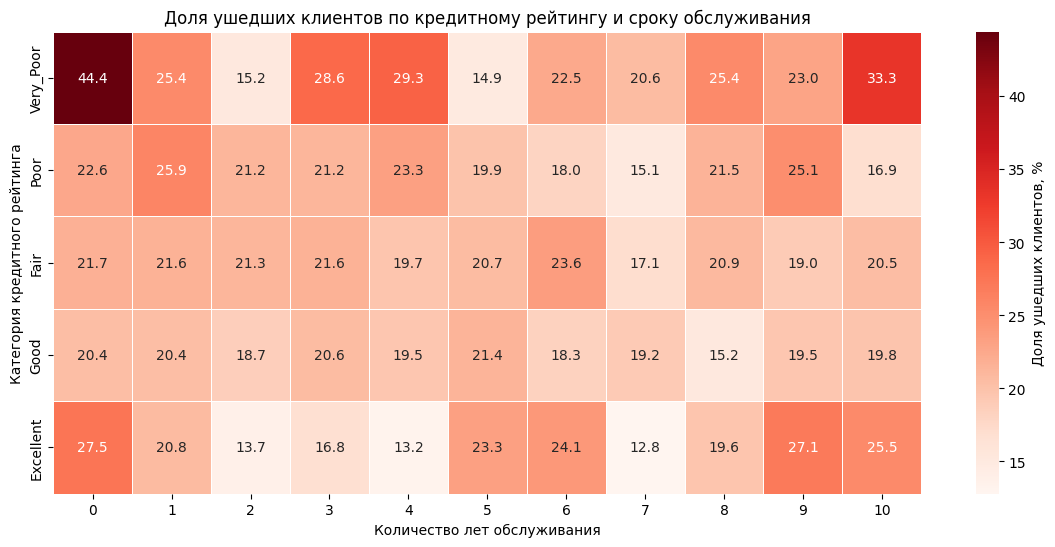

In [101]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot_table_percent,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Доля ушедших клиентов, %'}
)

plt.title('Доля ушедших клиентов по кредитному рейтингу и сроку обслуживания')
plt.xlabel('Количество лет обслуживания')
plt.ylabel('Категория кредитного рейтинга')

plt.show()

In [ ]:
max_churn = pivot_table_percent.stack().sort_values(ascending=False)
max_churn.head(10)

CreditScoreCat  Tenure
Very_Poor       0         44.4
                10        33.3
                4         29.3
                3         28.6
Excellent       0         27.5
                9         27.1
Poor            1         25.9
Excellent       10        25.5
Very_Poor       8         25.4
                1         25.4
dtype: float64